In [58]:
# textbook problem 1.12(a),(b)
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

data=np.array(pd.read_csv('/Users/liaoweihong/Desktop/Python/DAML/olympicman_randomordered.csv',header=None))
n=len(data)
# print(data)
partition=np.array([5,5,5,5,7])
data=np.split(data, [sum(partition[:i+1]) for i in range(len(partition)-1)])
# print(data)

lambv = [10**i for i in range(-12,3)]
sse = []

testx = data[0][:, 0]
testy = data[0][:, 1]
trainx = np.hstack([data[i][:, 0] for i in range(1, 5)])
trainy = np.hstack([data[i][:, 1] for i in range(1, 5)])
XT = [trainx**0, trainx**1]
X = np.array(XT).T

w = np.linalg.inv(X.T@X + lambv[0]*len(trainx)*np.identity(2)) @ X.T@trainy
sse.append((testy - w@[testx**i for i in range(2)])**2)



In [59]:
import math

def E(y):
    value = math.comb(10, y) * math.gamma(12)/(math.gamma(7)*math.gamma(5)) * (math.gamma(7+y)*math.gamma(15-y))/(math.gamma(15+y))
    return value

sum = 0
for i in range(7, 11):
    sum += E(i)
    
result = 1 - sum
print(round(result, 4))


0.8238


In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

# 讀取資料
data = np.array(pd.read_csv('/Users/liaoweihong/Desktop/Python/DAML/olympicman_randomordered.csv', header=None))
partition = np.array([5, 5, 5, 5, 7])
data = np.split(data, [sum(partition[:i+1]) for i in range(len(partition)-1)])

# 建立 lambda 值
lambv = [10**i for i in range(-12, 3)]
sse_all = []

# 對每個 lambda 進行 5-fold cross-validation
for lam in lambv:
    sse_fold = 0
    for i in range(5):  # 第 i 折作為測試集
        test = data[i]
        train = np.vstack([data[j] for j in range(5) if j != i])
        testx, testy = test[:, 0], test[:, 1]
        trainx, trainy = train[:, 0], train[:, 1]
        
        X_train = np.vstack([trainx**0, trainx**1]).T
        X_test = np.vstack([testx**0, testx**1]).T

        # Ridge regression
        w = np.linalg.inv(X_train.T @ X_train + lam * len(trainx) * np.identity(2)) @ (X_train.T @ trainy)
        y_pred = X_test @ w
        sse_fold += np.sum((testy - y_pred) ** 2)
    
    # 平均 SSE
    sse_all.append(sse_fold / 5)

# 畫圖
plt.semilogx(lambv, sse_all, marker='o')
plt.xlabel('lambda')
plt.ylabel('Average SSE (5-fold)')
plt.title('5-Fold Cross-Validation Ridge Regression')
plt.grid(True)
plt.show()

# 顯示最佳 lambda
best_lambda = lambv[np.argmin(sse_all)]
print(f'Best lambda: {best_lambda}')


TypeError: 'float' object is not callable

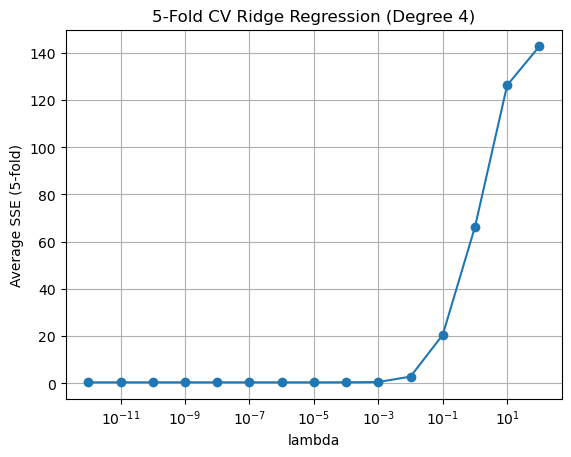

Best lambda (degree 4): 1e-12


In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

# 讀取資料
data = np.array(pd.read_csv('/Users/liaoweihong/Desktop/Python/DAML/olympicman_randomordered.csv', header=None))
partition = np.array([5, 5, 5, 5, 7])
data = np.split(data, [sum(partition[:i+1]) for i in range(len(partition)-1)])

# 建立 lambda 值
lambv = [10**i for i in range(-12, 3)]
sse_all = []

# 指定多項式次數
degree = 4

# 對每個 lambda 進行 5-fold cross-validation
for lam in lambv:
    sse_fold = 0
    for i in range(5):  # 第 i 折作為測試集
        test = data[i]
        train = np.vstack([data[j] for j in range(5) if j != i])
        
        testx, testy = test[:, 0], test[:, 1]
        trainx, trainy = train[:, 0], train[:, 1]
        
        # 建立多項式設計矩陣
        X_train = np.vstack([trainx**d for d in range(degree+1)]).T
        X_test = np.vstack([testx**d for d in range(degree+1)]).T

        # Ridge regression
        w = np.linalg.inv(X_train.T @ X_train + lam * len(trainx) * np.identity(degree+1)) @ (X_train.T @ trainy)
        y_pred = X_test @ w
        sse_fold += np.sum((testy - y_pred) ** 2)
    
    sse_all.append(sse_fold / 5)

# 畫圖
plt.semilogx(lambv, sse_all, marker='o')
plt.xlabel('lambda')
plt.ylabel('Average SSE (5-fold)')
plt.title(f'5-Fold CV Ridge Regression (Degree {degree})')
plt.grid(True)
plt.show()

# 顯示最佳 lambda
best_lambda = lambv[np.argmin(sse_all)]
print(f'Best lambda (degree {degree}): {best_lambda}')
